# Lung Cancer Classification — AAO + EfficientNetB0
**Dataset:** IQ-OTHNCCD Lung Cancer Augmented (Kaggle)  
**Optimizer:** Adaptive Aquila Optimizer (AAO) — latest mealpy  
**Deep Model:** EfficientNetB0 (Transfer Learning + Fine-Tuning)

## 1. Install Dependencies

In [1]:
!pip install kagglehub pywavelets imbalanced-learn scikit-image -q

## 2. Download Dataset via KaggleHub

In [2]:
import kagglehub

path = kagglehub.dataset_download("aleksandarcvetanov/iq-othnccd-lung-cancer-augmented-dataset")
print("Path to dataset files:", path)

# Inspect folder structure
import os
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files[:3]:
            print(f'{indent}  {f}')

100%|██████████| 951M/951M [00:11<00:00, 87.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/aleksandarcvetanov/iq-othnccd-lung-cancer-augmented-dataset/versions/3
3/
  The IQ-OTHNCCD Lung Cancer Augmented Dataset/
    IQ-OTH_NCCD Lung Cancer Dataset.txt
    Benign cases/
      Test/
      Train/
    Malignant cases/
      Test/
      Train/
    Normal cases/
      Test/
      Train/


In [3]:
# Auto-detect the dataset directory and categories
# The augmented dataset typically has subfolders: Benign, Malignant, Normal
DIRECTORY = None
CATEGORIES = None

# Walk to find the first folder containing image sub-directories
for root, dirs, files in os.walk(path):
    subdirs = [d for d in dirs if any(
        k in d.lower() for k in ['benign', 'bengin', 'malignant', 'normal']
    )]
    if subdirs:
        DIRECTORY = root
        CATEGORIES = sorted(subdirs)
        break

print(f'Dataset root: {DIRECTORY}')
print(f'Categories found: {CATEGORIES}')

Dataset root: /root/.cache/kagglehub/datasets/aleksandarcvetanov/iq-othnccd-lung-cancer-augmented-dataset/versions/3/The IQ-OTHNCCD Lung Cancer Augmented Dataset
Categories found: ['Benign cases', 'Malignant cases', 'Normal cases']


## 3. Import Packages

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2, random, pywt
from collections import Counter
from skimage import exposure

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                             f1_score, mean_squared_error, mean_absolute_error,
                             r2_score, roc_auc_score, roc_curve,
                             confusion_matrix, classification_report)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Latest mealpy AAO API
# from mealpy import FloatVar, AO

print('TF version:', tf.__version__)
# print('mealpy version:', mealpy.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
!pip install mealpy==2.5.1
# Latest mealpy AAO API
from mealpy.swarm_based import AO

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.3/383.3 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 56.7 MB/s eta 0:00:00


## 4. Configuration

In [6]:
IMG_SIZE = 224   # EfficientNetB0 default
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 5. EDA — Class Distribution

Class counts: {'Benign cases': 2, 'Malignant cases': 2, 'Normal cases': 2}


/tmp/ipython-input-3155879678.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


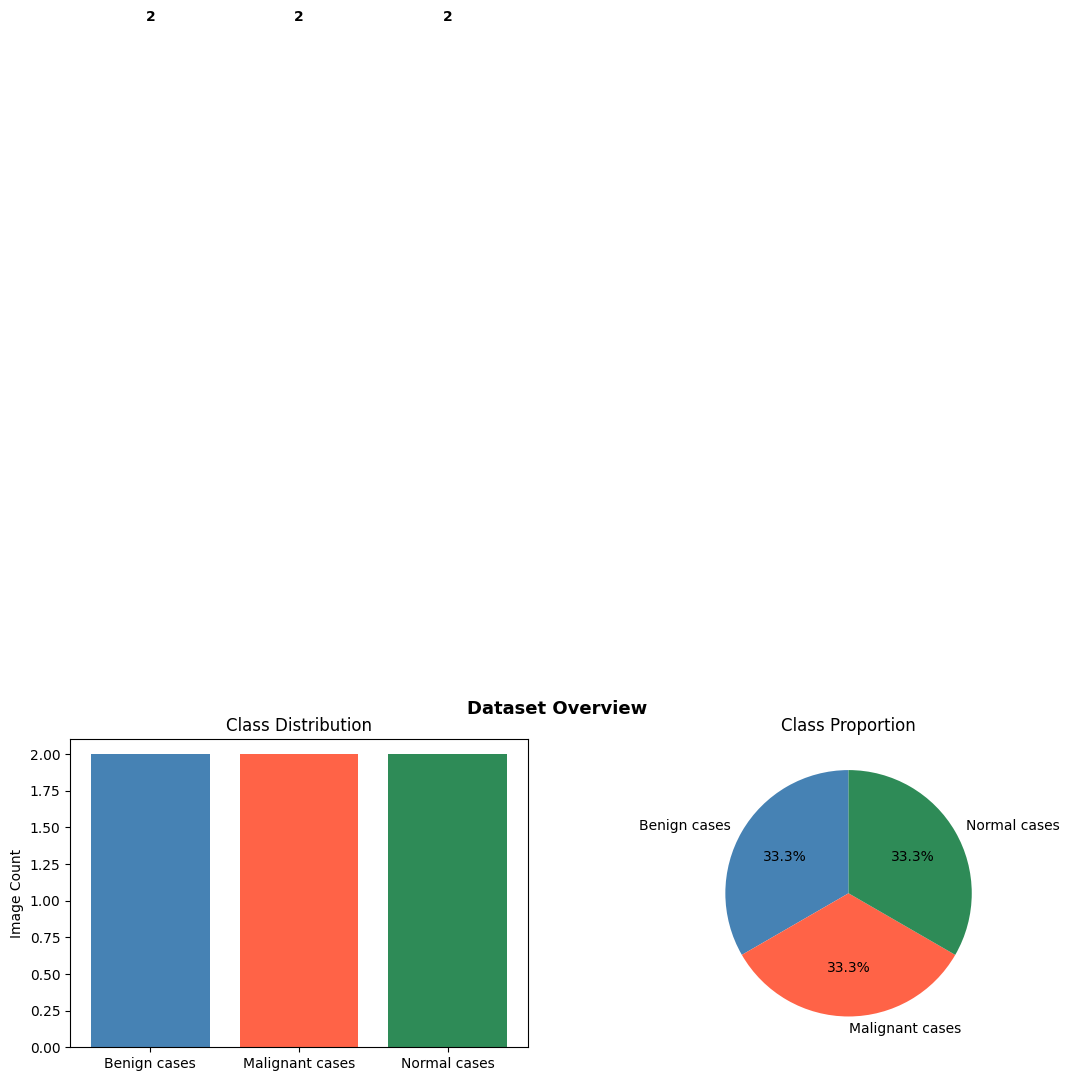

In [7]:
class_counts = {
    cat: len(os.listdir(os.path.join(DIRECTORY, cat)))
    for cat in CATEGORIES
}
print('Class counts:', class_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['steelblue', 'tomato', 'seagreen']

axes[0].bar(class_counts.keys(), class_counts.values(), color=colors)
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Image Count')
for i, (k, v) in enumerate(class_counts.items()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values(), labels=class_counts.keys(),
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Class Proportion')
plt.suptitle('Dataset Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Sample Images per Class

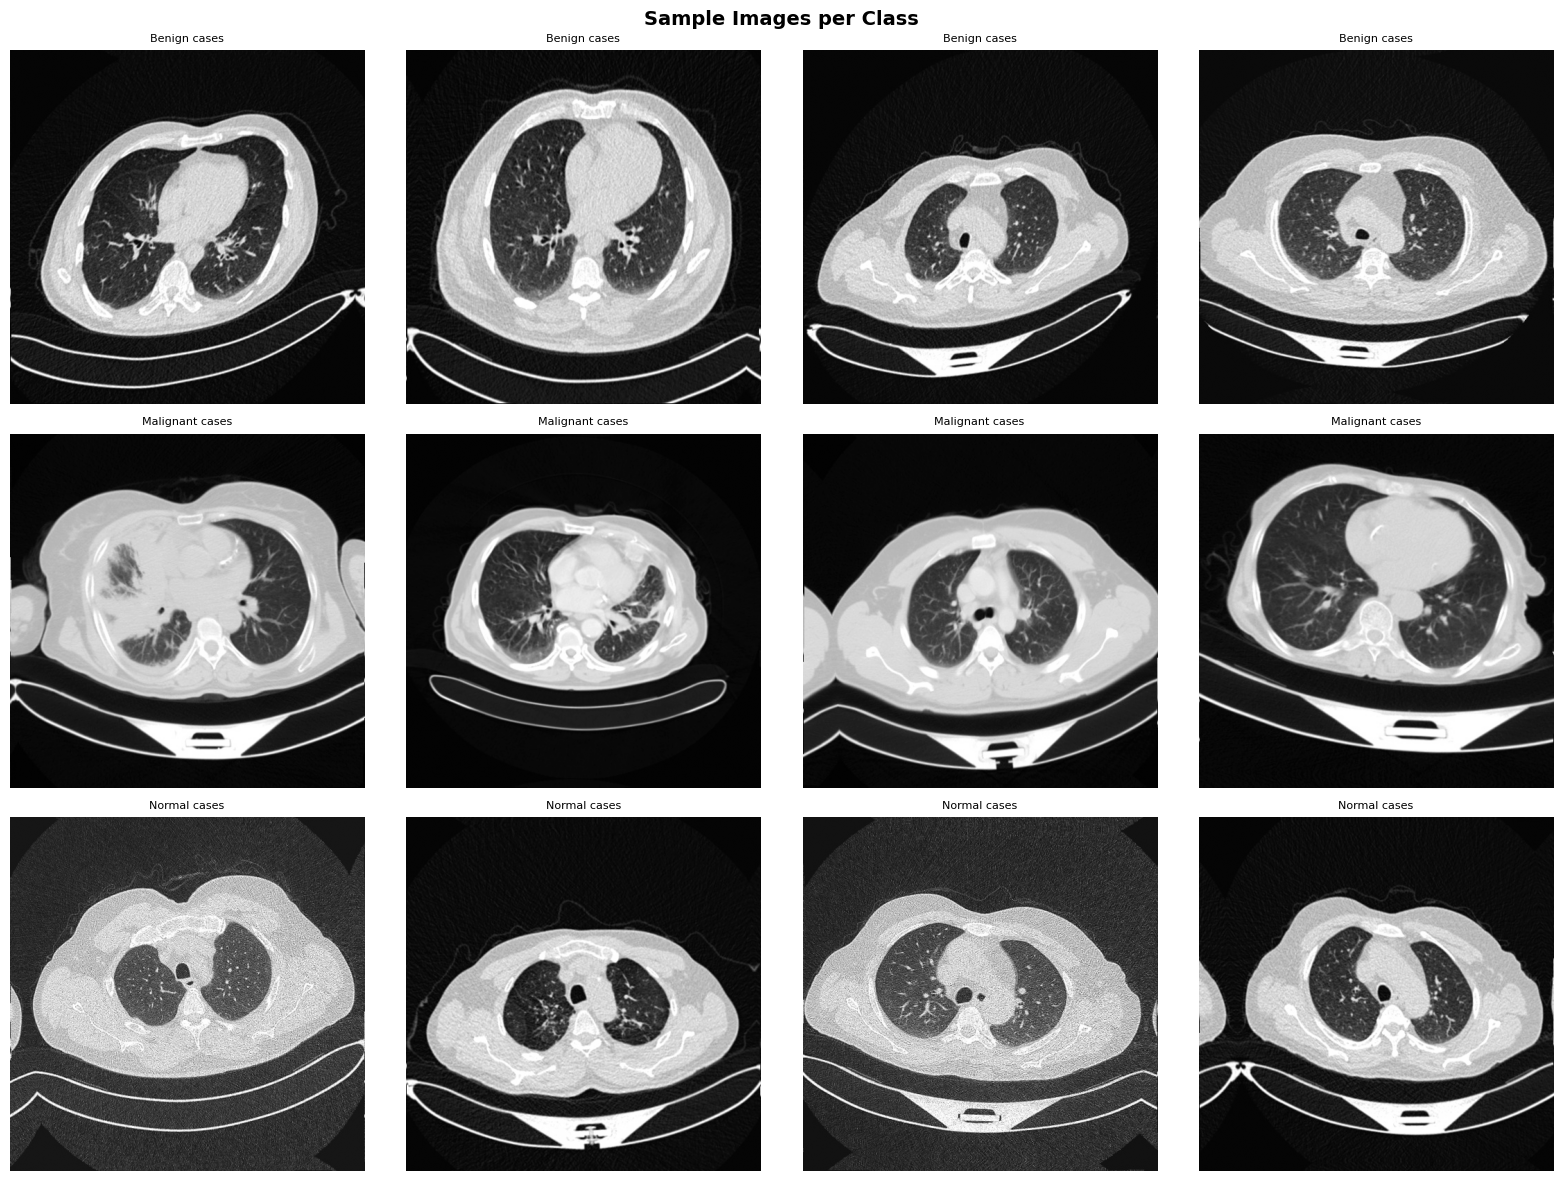

In [8]:
fig, axes = plt.subplots(len(CATEGORIES), 4, figsize=(16, 4 * len(CATEGORIES)))
fig.suptitle('Sample Images per Class', fontsize=14, fontweight='bold')

for r, cat in enumerate(CATEGORIES):
    # Collect all image files for the current category from both Test and Train subfolders
    category_image_files = []

    # Path to the current category folder (e.g., 'Benign cases')
    cat_base_path = os.path.join(DIRECTORY, cat)

    # Check for 'Test' and 'Train' subdirectories and collect image paths
    test_path = os.path.join(cat_base_path, 'Test')
    train_path = os.path.join(cat_base_path, 'Train')

    if os.path.isdir(test_path):
        category_image_files.extend([os.path.join(test_path, f) for f in os.listdir(test_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
    if os.path.isdir(train_path):
        category_image_files.extend([os.path.join(train_path, f) for f in os.listdir(train_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

    # Sample images from the collected list, ensuring not to sample more than available
    sampled_files = random.sample(category_image_files, min(4, len(category_image_files)))

    for c, file_path in enumerate(sampled_files):
        img = cv2.imread(file_path, 0)

        # Add a check for None in case an invalid file was read
        if img is None:
            print(f"Warning: Could not read image {file_path}. Skipping.")
            continue

        ax = axes[r, c] if len(CATEGORIES) > 1 else axes[c]
        ax.imshow(img, cmap='gray')
        ax.set_title(cat, fontsize=8)
        ax.axis('off')

plt.tight_layout()
plt.show()

## 7. Load & Resize Images

In [9]:
data = []
for i, cat in enumerate(CATEGORIES):
    cat_base_path = os.path.join(DIRECTORY, cat)

    # Collect images from 'Test' and 'Train' subdirectories
    for sub_dir in ['Test', 'Train']:
        current_path = os.path.join(cat_base_path, sub_dir)
        if os.path.isdir(current_path):
            for f in os.listdir(current_path):
                # Ensure it's a valid image file
                if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                    img_path = os.path.join(current_path, f)
                    img = cv2.imread(img_path, 0)
                    if img is not None:
                        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
                        data.append([img, i])

random.shuffle(data)
X_raw = np.array([d[0] for d in data])
y     = np.array([d[1] for d in data])

print(f'Total images loaded: {len(X_raw)} | Shape: {X_raw.shape}')
print('Label distribution:', Counter(y))

Total images loaded: 12184 | Shape: (12184, 224, 224)
Label distribution: Counter({np.int64(2): 4576, np.int64(1): 4488, np.int64(0): 3120})


## 8. Preprocessing Pipeline

In [ ]:
from tqdm import tqdm
import numpy as np
import cv2
from sklearn.ensemble import IsolationForest
import pywt
import gc

# Function to process images in batches
def process_images_in_batches(X, y, batch_size=32):
    n = len(X)
    for i in range(0, n, batch_size):
        yield X[i:i+batch_size], y[i:i+batch_size]

# Step 1: Normalize to [0, 1]
X_norm = X_raw / 255.0

# Step 2: Outlier removal — Isolation Forest (on flattened pixels)
iso = IsolationForest(contamination=0.05, random_state=SEED)
mask = iso.fit_predict(X_norm.reshape(len(X_norm), -1))
X_clean = X_norm[mask == 1]
y_clean = y[mask == 1]
print(f'After outlier removal: {len(X_clean)} images (removed {(mask == -1).sum()})')

# Clear temporary variables and invoke garbage collection
del X_norm
gc.collect()

# Step 3: Gaussian blur — noise suppression
X_blur = []
for img_batch in tqdm(process_images_in_batches(X_clean, y_clean), desc='Applying Gaussian Blur', leave=True):
    X_blur.append([cv2.GaussianBlur(img.astype('float32'), (3, 3), 0) for img in img_batch[0]])

# Flatten the list
X_blur = np.concatenate(X_blur)

gc.collect()

# Step 4: CLAHE — adaptive contrast enhancement
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
X_clahe = []
for img_batch in tqdm(process_images_in_batches(X_blur, y_clean), desc='Applying CLAHE', leave=True):
    X_clahe.append([clahe.apply((img * 255).astype(np.uint8)) / 255.0 for img in img_batch[0]])

# Flatten the list
X_clahe = np.concatenate(X_clahe)

gc.collect()

# Step 5: Wavelet LL sub-band denoising
def wavelet_ll(img):
    LL, _ = pywt.dwt2(img, 'bior1.3')
    LL = (LL - LL.min()) / (LL.max() - LL.min() + 1e-8)  # normalize
    return cv2.resize(LL, (IMG_SIZE, IMG_SIZE))

X_final = []
for img_batch in tqdm(process_images_in_batches(X_clahe, y_clean), desc='Wavelet Denoising', leave=True):
    X_final.append([wavelet_ll(img) for img in img_batch[0]])

# Flattening the list and converting to numpy array
X_final = np.concatenate(X_final)

print('Preprocessing done. Shape:', X_final.shape)

After outlier removal: 11574 images (removed 610)


Applying Gaussian Blur: 362it [00:02, 138.65it/s]


In [ ]:
from tqdm import tqdm
import pywt

# Step 1: Normalize to [0, 1]
X_norm = X_raw / 255.0

# Step 2: Outlier removal — Isolation Forest (on flattened pixels)
iso = IsolationForest(contamination=0.05, random_state=SEED)
mask = iso.fit_predict(X_norm.reshape(len(X_norm), -1))
X_clean = X_norm[mask == 1]
y_clean = y[mask == 1]
print(f'After outlier removal: {len(X_clean)} images (removed {(mask == -1).sum()})')

# Step 3: Gaussian blur — noise suppression
X_blur = np.array([
    cv2.GaussianBlur(img.astype('float32'), (3, 3), 0)
    for img in tqdm(X_clean, desc='Applying Gaussian Blur', leave=True)
])

# Step 4: CLAHE — adaptive contrast enhancement (better than plain histogram eq for medical)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
X_clahe = np.array([
    clahe.apply((img * 255).astype(np.uint8)) / 255.0
    for img in tqdm(X_blur, desc='Applying CLAHE', leave=True)
])

# Step 5: Wavelet LL sub-band denoising, resized back to IMG_SIZE
def wavelet_ll(img):
    LL, _ = pywt.dwt2(img, 'bior1.3')
    LL = (LL - LL.min()) / (LL.max() - LL.min() + 1e-8)  # normalize
    return cv2.resize(LL, (IMG_SIZE, IMG_SIZE))

X_final = np.array([wavelet_ll(img) for img in tqdm(X_clahe, desc='Wavelet Denoising', leave=True)])
print('Preprocessing done. Shape:', X_final.shape)


After outlier removal: 11574 images (removed 610)


Applying Gaussian Blur:  34%|███▍      | 3911/11574 [03:32<06:56, 18.38it/s]

In [ ]:
# Visualize preprocessing steps for one sample image
idx = 10
steps = [
    (X_raw[idx],    'Original'),
    (X_clean[idx],  'Normalized'),
    (X_blur[idx],   'Gaussian Blur'),
    (X_clahe[idx],  'CLAHE'),
    (X_final[idx],  'Wavelet LL'),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Preprocessing Pipeline — Step by Step', fontsize=13, fontweight='bold')
for ax, (img, title) in zip(axes, steps):
    ax.imshow(img, cmap='gray')
    ax.set_title(title, fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 9. Train/Test Split & SMOTE

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_clean, test_size=0.25, random_state=SEED, stratify=y_clean
)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

# SMOTE on flattened images
smote = SMOTE(random_state=SEED)
X_sm, y_sm = smote.fit_resample(
    X_train.reshape(len(X_train), -1), y_train
)
X_sm = X_sm.reshape(-1, IMG_SIZE, IMG_SIZE)

print('Before SMOTE:', Counter(y_train))
print('After  SMOTE:', Counter(y_sm))

# Visualize class balance before/after
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (counts, title) in zip(axes, [
    (Counter(y_train), 'Before SMOTE'),
    (Counter(y_sm),    'After SMOTE')
]):
    labels = [CATEGORIES[k] for k in sorted(counts)]
    values = [counts[k] for k in sorted(counts)]
    bars = ax.bar(labels, values, color=['steelblue','tomato','seagreen'])
    ax.bar_label(bars)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## 10. Baseline Classical Models

In [ ]:
X_tr_flat = X_sm.reshape(len(X_sm), -1)
X_te_flat = X_test.reshape(len(X_test), -1)

model_performance = pd.DataFrame(
    columns=['Accuracy','Recall','Precision','F1-Score','MSE','MAE','R2','ROC-AUC']
)

def evaluate(name, y_true, y_pred):
    yth = label_binarize(y_true, classes=[0,1,2])
    yph = label_binarize(y_pred, classes=[0,1,2])
    model_performance.loc[name] = [
        accuracy_score(y_true, y_pred),
        recall_score(y_true, y_pred, average='weighted'),
        precision_score(y_true, y_pred, average='weighted', zero_division=0),
        f1_score(y_true, y_pred, average='weighted'),
        mean_squared_error(y_true, y_pred),
        mean_absolute_error(y_true, y_pred),
        r2_score(y_true, y_pred),
        roc_auc_score(yth, yph, average='macro'),
    ]
    print(f'\n── {name} ──')
    print(classification_report(y_true, y_pred, target_names=CATEGORIES))

def plot_cm_roc(name, y_true, y_pred):
    yth = label_binarize(y_true, classes=[0,1,2])
    yph = label_binarize(y_pred, classes=[0,1,2])
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d',
                ax=axes[0], xticklabels=CATEGORIES, yticklabels=CATEGORIES, cmap='Blues')
    axes[0].set_title(f'{name} — Confusion Matrix')
    axes[0].tick_params(axis='x', rotation=20)

    for i, cat in enumerate(CATEGORIES):
        fpr, tpr, _ = roc_curve(yth[:, i], yph[:, i])
        auc = roc_auc_score(yth[:, i], yph[:, i])
        axes[1].plot(fpr, tpr, label=f'{cat} (AUC={auc:.2f})')
    axes[1].plot([0,1],[0,1],'--', color='gray')
    axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
    axes[1].set_title(f'{name} — ROC Curve')
    axes[1].legend(fontsize=8)
    plt.tight_layout(); plt.show()

# ── KNN ──────────────────────────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_tr_flat, y_sm)
pred = knn.predict(X_te_flat)
evaluate('KNN', y_test, pred); plot_cm_roc('KNN', y_test, pred)

# ── Decision Tree ─────────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(random_state=SEED)
dt.fit(X_tr_flat, y_sm)
pred = dt.predict(X_te_flat)
evaluate('DecisionTree', y_test, pred); plot_cm_roc('DecisionTree', y_test, pred)

# ── Random Forest ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=SEED)
rf.fit(X_tr_flat, y_sm)
pred = rf.predict(X_te_flat)
evaluate('RandomForest', y_test, pred); plot_cm_roc('RandomForest', y_test, pred)

# ── SVM ───────────────────────────────────────────────────────────────────────
svm = SVC(kernel='rbf', C=1, random_state=SEED)
svm.fit(X_tr_flat, y_sm)
pred = svm.predict(X_te_flat)
evaluate('SVM', y_test, pred); plot_cm_roc('SVM', y_test, pred)

## 11. Convert Grayscale → RGB for EfficientNetB0

In [ ]:
def to_rgb(X_gray):
    return np.array([
        cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_GRAY2RGB)
        for img in X_gray
    ])

X_tr_rgb = to_rgb(X_sm)
X_te_rgb = to_rgb(X_test)
print('Train RGB:', X_tr_rgb.shape, '| Test RGB:', X_te_rgb.shape)

## 12. Adaptive Aquila Optimizer (AAO) — Hyperparameter Tuning

AAO searches for the best **learning rate**, **dropout rate**, and **training epochs** for EfficientNetB0.

In [ ]:
def build_efficientnet(lr=1e-4, dropout=0.4):
    """Build EfficientNetB0 with frozen backbone."""
    base = EfficientNetB0(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    model = Sequential([
        base,
        GlobalAveragePooling2D(),
        Dropout(dropout),
        Dense(128, activation='relu'),
        Dropout(dropout / 2),
        Dense(3, activation='softmax')
    ])
    model.compile(
        optimizer=Adam(lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Use a small proxy subset to keep AAO fast
PROXY_N   = 300
PROXY_VAL = 80

def aao_objective(solution):
    """
    solution[0]: learning rate exponent  → lr = 10^solution[0]  (range -5 to -2)
    solution[1]: dropout rate            → range 0.2 to 0.6
    solution[2]: training epochs         → int, range 5 to 20
    Returns: validation loss (minimise)
    """
    lr      = 10 ** solution[0]
    dropout = solution[1]
    epochs  = max(3, int(solution[2]))

    m = build_efficientnet(lr=lr, dropout=dropout)
    es = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
    hist = m.fit(
        X_tr_rgb[:PROXY_N], y_sm[:PROXY_N],
        validation_data=(X_te_rgb[:PROXY_VAL], y_test[:PROXY_VAL]),
        epochs=epochs, batch_size=16,
        callbacks=[es], verbose=0
    )
    val_loss = min(hist.history['val_loss'])
    print(f'  lr={lr:.2e}, dropout={dropout:.3f}, epochs={epochs} → val_loss={val_loss:.4f}')
    return val_loss

# ── AAO Problem Definition (latest mealpy API) ────────────────────────────────
problem_dict = {
    "bounds": FloatVar(
        n_vars=3,
        lb=(-5.0, 0.2,  5.0),   # lr_exp, dropout, epochs
        ub=(-2.0, 0.6, 20.0),
        name="hyperparams"
    ),
    "obj_func": aao_objective,
    "minmax": "min",
    "log_to": "console"
}

# ── Run AAO ───────────────────────────────────────────────────────────────────
# epoch/pop_size kept small for Colab; increase for better optimisation
aao_model = AO.AAO(epoch=10, pop_size=5, sharpness=10.0, sigmoid_midpoint=0.5)
g_best = aao_model.solve(problem_dict)

best_lr      = 10 ** g_best.solution[0]
best_dropout = g_best.solution[1]
best_epochs  = max(3, int(g_best.solution[2]))

print(f'\n✅ AAO Best Solution:')
print(f'   Learning Rate : {best_lr:.2e}')
print(f'   Dropout       : {best_dropout:.4f}')
print(f'   Epochs        : {best_epochs}')
print(f'   Val Loss (fit): {g_best.target.fitness:.4f}')

In [ ]:
# AAO convergence visualisation
plt.figure(figsize=(9, 4))
plt.plot(aao_model.history.list_global_best_fit,
         marker='o', color='royalblue', label='Global Best')
plt.plot(aao_model.history.list_current_best_fit,
         alpha=0.5, color='orange', label='Current Best')
plt.xlabel('Iteration')
plt.ylabel('Validation Loss')
plt.title('AAO Convergence Curve')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 13. Train Final EfficientNetB0 (Phase 1 — Frozen Backbone)

In [ ]:
final_model = build_efficientnet(lr=best_lr, dropout=best_dropout)
final_model.summary()

es_p1 = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

history_p1 = final_model.fit(
    X_tr_rgb, y_sm,
    validation_data=(X_te_rgb, y_test),
    epochs=best_epochs,
    batch_size=32,
    callbacks=[es_p1]
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(history_p1.history[metric],       label='Train')
    ax.plot(history_p1.history[f'val_{metric}'], label='Validation')
    ax.set_title(f'Phase 1 — {metric.capitalize()}')
    ax.set_xlabel('Epoch'); ax.set_ylabel(metric.capitalize())
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('EfficientNetB0 — Phase 1 Training (Frozen Backbone)', fontweight='bold')
plt.tight_layout(); plt.show()

y_pred_p1 = np.argmax(final_model.predict(X_te_rgb), axis=1)
evaluate('AAO+EfficientNetB0 (P1)', y_test, y_pred_p1)
plot_cm_roc('AAO+EfficientNetB0 (P1)', y_test, y_pred_p1)

## 14. Fine-Tuning (Phase 2 — Unfreeze Top Layers)

In [ ]:
# Unfreeze top 20 layers of EfficientNet backbone
backbone = final_model.layers[0]
for layer in backbone.layers[-20:]:
    layer.trainable = True

# Lower LR for fine-tuning to avoid destroying learned weights
final_model.compile(
    optimizer=Adam(best_lr / 10),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es_p2 = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)
history_p2 = final_model.fit(
    X_tr_rgb, y_sm,
    validation_data=(X_te_rgb, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[es_p2]
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(history_p2.history[metric],          label='Train')
    ax.plot(history_p2.history[f'val_{metric}'], label='Validation')
    ax.set_title(f'Phase 2 — {metric.capitalize()}')
    ax.set_xlabel('Epoch'); ax.set_ylabel(metric.capitalize())
    ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('EfficientNetB0 — Phase 2 Fine-Tuning', fontweight='bold')
plt.tight_layout(); plt.show()

y_pred_p2 = np.argmax(final_model.predict(X_te_rgb), axis=1)
evaluate('AAO+EfficientNetB0 (P2-FineTuned)', y_test, y_pred_p2)
plot_cm_roc('AAO+EfficientNetB0 (P2-FineTuned)', y_test, y_pred_p2)

## 15. Final Model Comparison

In [ ]:
print('\n======== Model Performance Summary ========')
display(
    model_performance
    .sort_values('Accuracy', ascending=False)
    .style
    .background_gradient(cmap='RdYlGn')
    .format('{:.4f}')
    .set_caption('All Models — Performance Metrics')
)

In [ ]:
# Side-by-side bar chart for key metrics
metrics_to_plot = ['Accuracy', 'F1-Score', 'ROC-AUC']
mp = model_performance[metrics_to_plot].sort_values('Accuracy', ascending=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmap = plt.cm.Set2.colors

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.barh(mp.index, mp[metric],
                   color=cmap[:len(mp)], edgecolor='white')
    ax.set_xlim(0, 1.1)
    ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Model Comparison — All Classifiers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Save All Models

In [ ]:
from joblib import dump
dump(knn, 'knn_model.joblib')
dump(dt,  'decision_tree_model.joblib')
dump(rf,  'random_forest_model.joblib')
dump(svm, 'svm_model.joblib')
final_model.save('aao_efficientnetb0_lungcancer.h5')
print('✅ All models saved successfully.')